1. Import Libraries

In [41]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [42]:
df = pd.read_csv("/content/cleaned_telco.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [43]:
df.shape

(7043, 21)

Create Engineered Features

Tenure Bucket

In [44]:
df["TenureBucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

In [45]:
df["TenureBucket"].value_counts()

,count
TenureBucket,
4-6 Years,2239
0-1 Year,2175
2-4 Years,1594
1-2 Years,1024


Family Indicator

In [46]:
df["FamilyIndicator"] = (
    (df["Partner"] == "Yes") |
    (df["Dependents"] == "Yes")
).astype(int)

In [47]:
df["FamilyIndicator"].value_counts()

,count
FamilyIndicator,
1,3763
0,3280


Support Bundle

In [48]:
support_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

df["SupportBundle"] = (
    (df[support_cols] == "Yes")
    .sum(axis=1)
)

In [49]:
df["SupportBundle"].describe()

,SupportBundle
count,7043.000000
mean,1.265654
std,1.286879
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4.000000


Streaming Bundle

In [50]:
stream_cols = [
    "StreamingTV",
    "StreamingMovies"
]

df["StreamingBundle"] = (
    (df[stream_cols] == "Yes")
    .sum(axis=1)
)

Charge Per Month

In [51]:
# Charge per month
df["ChargePerMonth"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

Total subscribed services

In [52]:
service_cols = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [53]:
df["ServiceCount"] = (
    (df[service_cols] == "Yes")
    .sum(axis=1)
)

Inspect New Features

In [54]:
df[
    [
        "TenureBucket",
        "FamilyIndicator",
        "SupportBundle",
        "StreamingBundle",
        "ChargePerMonth",
        "ServiceCount"
    ]
].head()

,TenureBucket,FamilyIndicator,SupportBundle,StreamingBundle,ChargePerMonth,ServiceCount
0,0-1 Year,1,1,0,14.925000,1
1,2-4 Years,0,2,0,53.985714,3
2,0-1 Year,0,2,0,36.050000,3
3,2-4 Years,0,3,0,40.016304,3
4,0-1 Year,0,0,0,50.550000,1


Correlation with Churn

In [55]:
temp = df.copy()

temp["TenureBucket"] = temp["TenureBucket"].cat.codes

In [56]:
numeric = temp.select_dtypes(include=["int64", "float64"])

In [57]:
corr = numeric.corr()

corr["Churn"].sort_values(
    key=abs,
    ascending=False
)

,Churn
Churn,1.000000
tenure,-0.352229
TotalCharges,-0.199037
MonthlyCharges,0.193356
SupportBundle,-0.173061
FamilyIndicator,-0.162835
SeniorCitizen,0.150889
ServiceCount,-0.085963
StreamingBundle,0.071162
ChargePerMonth,0.014873


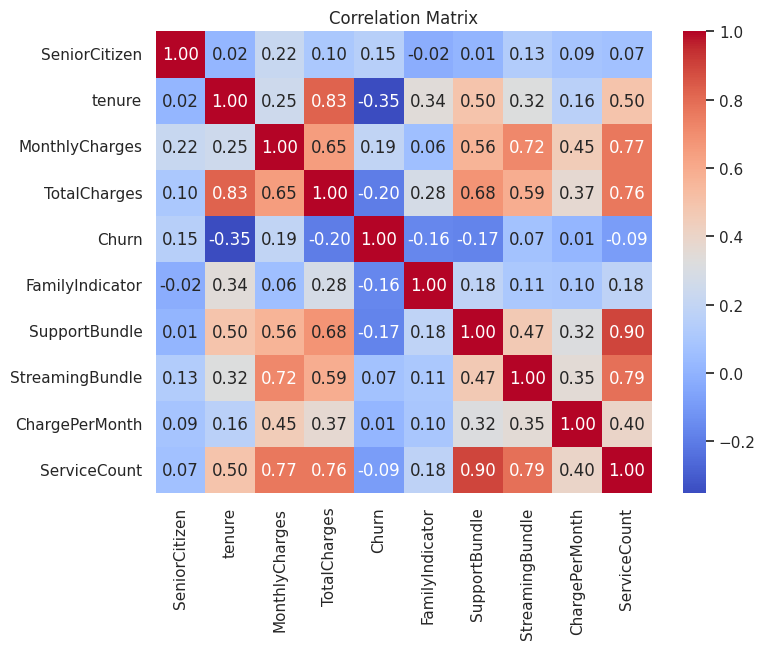

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Compare New Features with Churn

SupportBundle

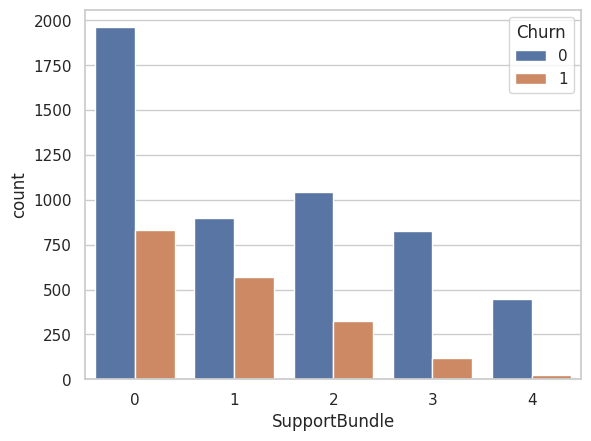

In [59]:
sns.countplot(
    x="SupportBundle",
    hue="Churn",
    data=df
)

plt.show()

FamilyIndicator

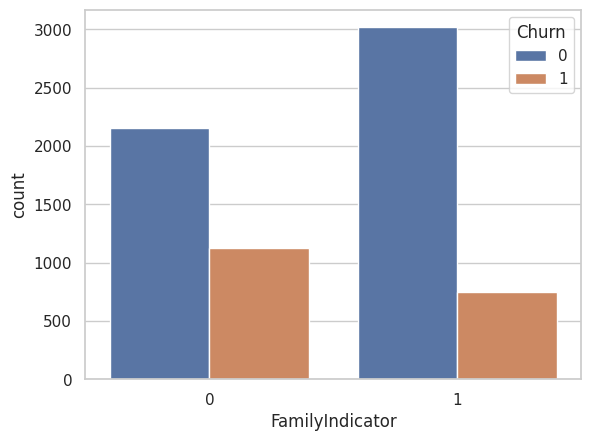

In [60]:
sns.countplot(
    x="FamilyIndicator",
    hue="Churn",
    data=df
)

plt.show()

TenureBucket

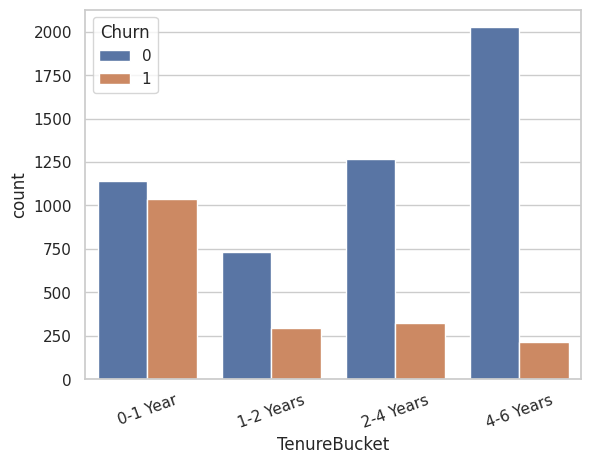

In [61]:
sns.countplot(
    x="TenureBucket",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)
plt.show()

StreamingBundle

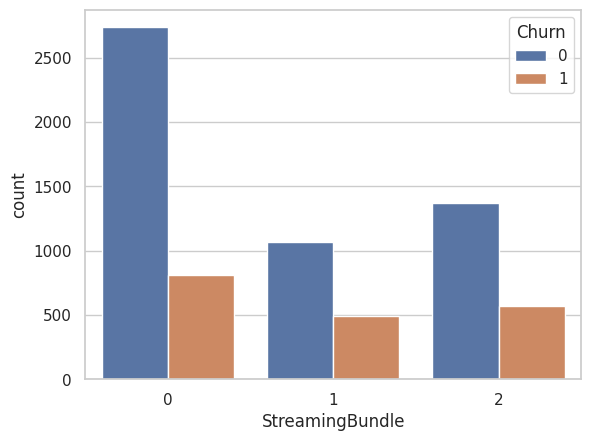

In [62]:
sns.countplot(
    x="StreamingBundle",
    hue="Churn",
    data=df
)

plt.show()

Service Count

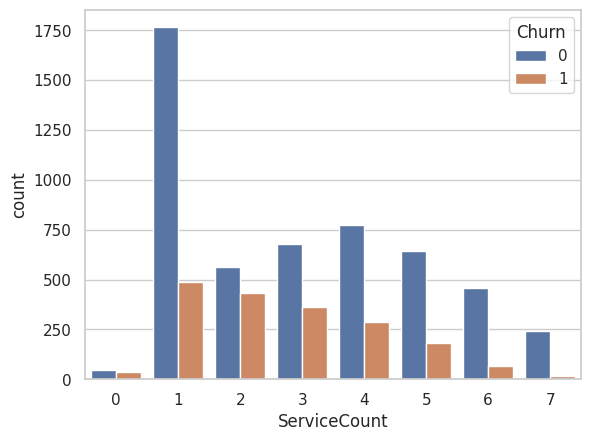

In [63]:
sns.countplot(
    x="ServiceCount",
    hue="Churn",
    data=df
)

plt.show()

ChargePerMonth

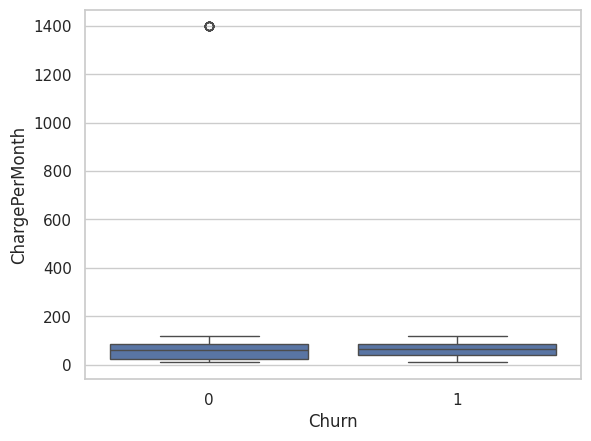

In [64]:
sns.boxplot(
    x="Churn",
    y="ChargePerMonth",
    data=df
)

plt.show()

Check for Redundant Features

Remove Redundant Features

In [66]:
df.drop(
    columns=[
        "ChargePerMonth",
        "ServiceCount"
    ],
    inplace=True
)

In [67]:
df.to_csv(
    "enhanced_telco.csv",
    index=False
)

print("Enhanced dataset saved as enhanced_telco.csv")

Enhanced dataset saved as enhanced_telco.csv


# Feature Engineering Summary

## Candidate Features Created

* TenureBucket
* FamilyIndicator
* SupportBundle
* StreamingBundle
* ChargePerMonth
* ServiceCount

## Evaluation Process

Each engineered feature was evaluated using:

* Correlation with Churn
* Correlation heatmaps
* Redundancy analysis
* Distribution plots

## Findings

### TenureBucket

Captures customer lifecycle stages and separates short-term and long-term customers.

### FamilyIndicator

Shows a moderate negative relationship with churn and may capture household stability.

### SupportBundle

One of the strongest engineered predictors. Customers using more support-related services tend to churn less.

### StreamingBundle

Shows a weak but non-redundant relationship with churn and is retained for model testing.

### ChargePerMonth

Very weak correlation with churn (0.015). Removed due to low predictive value.

### ServiceCount

Highly correlated with SupportBundle (0.90) and StreamingBundle (0.79). Removed due to redundancy.

## Final Features Retained

* TenureBucket
* FamilyIndicator
* SupportBundle
* StreamingBundle

## Features Removed

* ChargePerMonth
* ServiceCount

The enhanced dataset was saved as enhanced_telco.csv for use in model development.
